In [1]:
from random import choice
import os
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D
from skimage.feature import peak_local_max
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, bootstrap
from skimage.feature import peak_local_max

from scipy.stats import ttest_ind, mannwhitneyu

C:\Users\cmurua\Anaconda3\envs\Nominate_v2\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\cmurua\Anaconda3\envs\Nominate_v2\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\cmurua\Anaconda3\envs\Nominate_v2\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:

chile_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40.xlsx')
chile_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40.xlsx')

chile_menores40_der = chile_menores40[(chile_menores40['Age']=='<40')&(chile_menores40['Politica']=='Right')]
chile_menores40_iz = chile_menores40[(chile_menores40['Age']=='<40')&(chile_menores40['Politica']=='Left')]

chile_mayores40_der= chile_mayores40[(chile_mayores40['Age']=='>40')&(chile_mayores40['Politica']=='Right')]
chile_mayores40_iz= chile_mayores40[(chile_mayores40['Age']=='>40')&(chile_mayores40['Politica']=='Left')]


# Inicializar una lista para almacenar las distancias
distancias_mayor40_Chile = []
distancias_menor40_Chile = []

# Calcular la distancia entre todas las filas
for i in range(len(chile_mayores40_iz)):
    z1_iz_ma = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma = chile_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me = chile_menores40_iz.iloc[i]['z2']
    z1_der_me = chile_menores40_der.iloc[i]['z1']
    z2_der_me = chile_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Chile.append(distancia_ma)
    distancias_menor40_Chile.append(distancia_me)
    

In [3]:
# Leer los archivos de Excel para Brasil
brasil_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40_Brasil.xlsx')
brasil_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40_Brasil.xlsx')

# Filtrar por edad y orientación política para menores de 40
brasil_menores40_der = brasil_menores40[(brasil_menores40['Age']=='<40') & (brasil_menores40['Politica']=='Right')]
brasil_menores40_iz = brasil_menores40[(brasil_menores40['Age']=='<40') & (brasil_menores40['Politica']=='Left')]

# Filtrar por edad y orientación política para mayores de 40
brasil_mayores40_der = brasil_mayores40[(brasil_mayores40['Age']=='>40') & (brasil_mayores40['Politica']=='Right')]
brasil_mayores40_iz = brasil_mayores40[(brasil_mayores40['Age']=='>40') & (brasil_mayores40['Politica']=='Left')]

# Inicializar listas para almacenar las distancias
distancias_mayor40_Brasil = []
distancias_menor40_Brasil = []

# Calcular la distancia entre todas las filas
for i in range(len(brasil_mayores40_iz)):
    z1_iz_ma = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma = brasil_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me = brasil_menores40_der.iloc[i]['z1']
    z2_der_me = brasil_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Brasil.append(distancia_ma)
    distancias_menor40_Brasil.append(distancia_me)


In [4]:
# Leer los archivos de Excel para Francia
francia_mayores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_mayores40_Francia.xlsx')
francia_menores40 = pd.read_excel('Coordenadas/Coordenadas_peaks_menores40_Francia.xlsx')

# Filtrar por edad y orientación política para menores de 40
francia_menores40_der = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Right')]
francia_menores40_iz = francia_menores40[(francia_menores40['Age']=='<40') & (francia_menores40['Politica']=='Left')]

# Filtrar por edad y orientación política para mayores de 40
francia_mayores40_der = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Right')]
francia_mayores40_iz = francia_mayores40[(francia_mayores40['Age']=='>40') & (francia_mayores40['Politica']=='Left')]

# Inicializar listas para almacenar las distancias
distancias_mayor40_Francia = []
distancias_menor40_Francia = []

# Calcular la distancia entre todas las filas
for i in range(len(francia_mayores40_iz)):
    z1_iz_ma = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma = francia_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me = francia_menores40_iz.iloc[i]['z2']
    z1_der_me = francia_menores40_der.iloc[i]['z1']
    z2_der_me = francia_menores40_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_ma = np.sqrt((z1_der_ma - z1_iz_ma) ** 2 + (z2_der_ma - z2_iz_ma) ** 2)
    distancia_me = np.sqrt((z1_der_me - z1_iz_me) ** 2 + (z2_der_me - z2_iz_me) ** 2)
    
    # Agregar la distancia a la lista
    distancias_mayor40_Francia.append(distancia_ma)
    distancias_menor40_Francia.append(distancia_me)


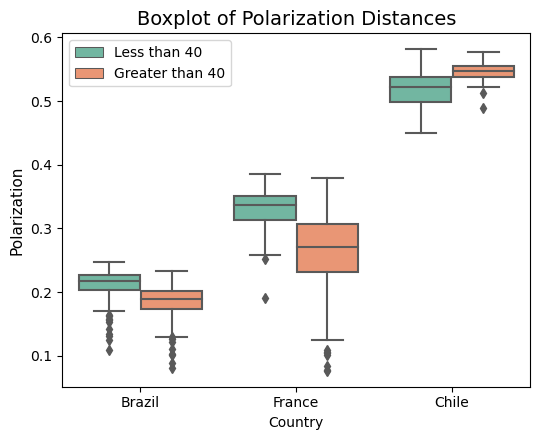

In [5]:
#Crear un DataFrame para facilitar la creación del boxplot
data = {
    'Country': (
        ['Brazil'] * 200 + ['Brazil'] * 200 +
        ['France'] * 200 + ['France'] * 200 +
        ['Chile'] * 200 + ['Chile'] * 200
    ),
    'Age Group': (
        ['Less than 40'] * 200 + ['Greater than 40'] * 200 +
        ['Less than 40'] * 200 + ['Greater than 40'] * 200 +
        ['Less than 40'] * 200 + ['Greater than 40'] * 200
    ),
    'Distance': np.concatenate([
        distancias_menor40_Brasil, distancias_mayor40_Brasil,
        distancias_menor40_Francia, distancias_mayor40_Francia,
        distancias_menor40_Chile, distancias_mayor40_Chile
    ])
}

df = pd.DataFrame(data)

# Configurar el gráfico
plt.figure(figsize=(5.5, 4.5))
sns.boxplot(x='Country', y='Distance', hue='Age Group', data=df, palette="Set2")

# Títulos y etiquetas de los ejes
plt.title('Boxplot of Polarization Distances', fontsize=14)
plt.xlabel('Country', fontsize=10)
plt.ylabel('Polarization', fontsize=11)

# Ajustar las etiquetas de la leyenda
plt.legend( fontsize=10)

# Ajustar el tamaño de las etiquetas en los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el gráfico para que no se superpongan los elementos
plt.show()


In [6]:
# Cargar datos de Brasil y Francia
brasil = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers_Brasil.xlsx')
francia = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers_Francia.xlsx')
chile = pd.read_excel('Coordenadas/Coordenadas_peaks_AllUsers.xlsx')


# Filtrar por política para Brasil
der_brasil = brasil[brasil['Politica'] == 'Right']
iz_brasil = brasil[brasil['Politica'] == 'Left']
iz_chile = chile[chile['Politica']=='Left']

# Filtrar por política para Francia
der_francia = francia[francia['Politica'] == 'Right']
iz_francia = francia[francia['Politica'] == 'Left']
der_chile = chile[chile['Politica']=='Right']


In [7]:
# Inicializar listas para almacenar las distancias
distancias_der_all_ma = []
distancias_iz_all_ma = []
distancias_der_all_me = []
distancias_iz_all_me = []


# Calcular la distancia entre todas las filas
for i in range(len(francia_mayores40_iz)):
    z1_iz_ma = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma = francia_mayores40_der.iloc[i]['z2']
    
    z1_iz_me = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me = francia_menores40_iz.iloc[i]['z2']
    z1_der_me = francia_menores40_der.iloc[i]['z1']
    z2_der_me = francia_menores40_der.iloc[i]['z2']
    
    z1_iz_all = iz_francia.iloc[i]['z1']
    z2_iz_all = iz_francia.iloc[i]['z2']
    z1_der_all = der_francia.iloc[i]['z1']
    z2_der_all = der_francia.iloc[i]['z2']
    
     # Calcular distancias
    distancia_der_all_ma = np.sqrt((z1_der_all - z1_der_ma) ** 2 + (z2_der_all - z2_der_ma) ** 2)
    distancia_iz_all_ma = np.sqrt((z1_iz_all - z1_iz_ma) ** 2 + (z2_iz_all - z2_iz_ma) ** 2)
    
    distancia_der_all_me = np.sqrt((z1_der_all - z1_der_me) ** 2 + (z2_der_all - z2_der_me) ** 2)
    distancia_iz_all_me = np.sqrt((z1_iz_all - z1_iz_me) ** 2 + (z2_iz_all - z2_iz_me) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma.append(distancia_der_all_ma)
    distancias_iz_all_ma.append(distancia_iz_all_ma)
    distancias_der_all_me.append(distancia_der_all_me)
    distancias_iz_all_me.append(distancia_iz_all_me)

    

    # Inicializar listas para almacenar las distancias
distancias_der_all_ma_chile = []
distancias_iz_all_ma_chile = []
distancias_der_all_me_chile = []
distancias_iz_all_me_chile = []

distancias_der_all_ma_brasil = []
distancias_iz_all_ma_brasil = []
distancias_der_all_me_brasil = []
distancias_iz_all_me_brasil = []

# Calcular la distancia para Chile (mayores de 40 y menores de 40)
for i in range(len(chile_mayores40_iz)):
    # Coordenadas para Chile (mayores de 40)
    z1_iz_ma_chile = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_chile = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma_chile = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma_chile = chile_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (menores de 40)
    z1_iz_me_chile = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me_chile = chile_menores40_iz.iloc[i]['z2']
    z1_der_me_chile = chile_menores40_der.iloc[i]['z1']
    z2_der_me_chile = chile_menores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (all users)
    z1_iz_all_chile = iz_chile.iloc[i]['z1']
    z2_iz_all_chile = iz_chile.iloc[i]['z2']
    z1_der_all_chile = der_chile.iloc[i]['z1']
    z2_der_all_chile = der_chile.iloc[i]['z2']
    
    # Calcular distancias para Chile
    distancia_der_all_ma_chile = np.sqrt((z1_der_all_chile - z1_der_ma_chile) ** 2 + (z2_der_all_chile - z2_der_ma_chile) ** 2)
    distancia_iz_all_ma_chile = np.sqrt((z1_iz_all_chile - z1_iz_ma_chile) ** 2 + (z2_iz_all_chile - z2_iz_ma_chile) ** 2)
    
    distancia_der_all_me_chile = np.sqrt((z1_der_all_chile - z1_der_me_chile) ** 2 + (z2_der_all_chile - z2_der_me_chile) ** 2)
    distancia_iz_all_me_chile = np.sqrt((z1_iz_all_chile - z1_iz_me_chile) ** 2 + (z2_iz_all_chile - z2_iz_me_chile) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma_chile.append(distancia_der_all_ma_chile)
    distancias_iz_all_ma_chile.append(distancia_iz_all_ma_chile)
    distancias_der_all_me_chile.append(distancia_der_all_me_chile)
    distancias_iz_all_me_chile.append(distancia_iz_all_me_chile)

# Calcular la distancia para Brasil (mayores de 40 y menores de 40)
for i in range(len(brasil_mayores40_iz)):
    # Coordenadas para Brasil (mayores de 40)
    z1_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma_brasil = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma_brasil = brasil_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (menores de 40)
    z1_iz_me_brasil = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me_brasil = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me_brasil = brasil_menores40_der.iloc[i]['z1']
    z2_der_me_brasil = brasil_menores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (all users)
    z1_iz_all_brasil = iz_brasil.iloc[i]['z1']
    z2_iz_all_brasil = iz_brasil.iloc[i]['z2']
    z1_der_all_brasil = der_brasil.iloc[i]['z1']
    z2_der_all_brasil = der_brasil.iloc[i]['z2']
    
    # Calcular distancias para Brasil
    distancia_der_all_ma_brasil = np.sqrt((z1_der_all_brasil - z1_der_ma_brasil) ** 2 + (z2_der_all_brasil - z2_der_ma_brasil) ** 2)
    distancia_iz_all_ma_brasil = np.sqrt((z1_iz_all_brasil - z1_iz_ma_brasil) ** 2 + (z2_iz_all_brasil - z2_iz_ma_brasil) ** 2)
    
    distancia_der_all_me_brasil = np.sqrt((z1_der_all_brasil - z1_der_me_brasil) ** 2 + (z2_der_all_brasil - z2_der_me_brasil) ** 2)
    distancia_iz_all_me_brasil = np.sqrt((z1_iz_all_brasil - z1_iz_me_brasil) ** 2 + (z2_iz_all_brasil - z2_iz_me_brasil) ** 2)
    
    # Agregar distancias a las listas
    distancias_der_all_ma_brasil.append(distancia_der_all_ma_brasil)
    distancias_iz_all_ma_brasil.append(distancia_iz_all_ma_brasil)
    distancias_der_all_me_brasil.append(distancia_der_all_me_brasil)
    distancias_iz_all_me_brasil.append(distancia_iz_all_me_brasil)



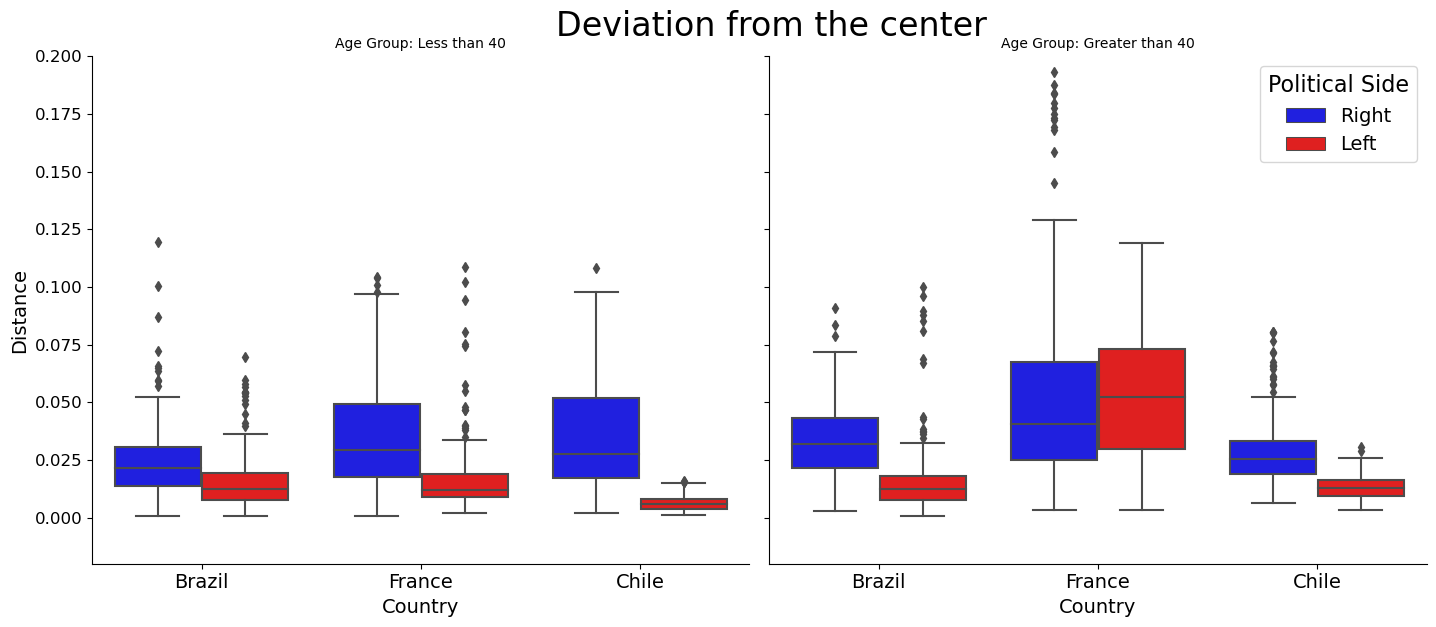

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame con todas las distancias
data = {
    'Country': ['France'] * (len(distancias_der_all_me) + len(distancias_iz_all_me) + len(distancias_der_all_ma) + len(distancias_iz_all_ma)) +
               ['Chile'] * (len(distancias_der_all_me_chile) + len(distancias_iz_all_me_chile) + len(distancias_der_all_ma_chile) + len(distancias_iz_all_ma_chile)) +
               ['Brazil'] * (len(distancias_der_all_me_brasil) + len(distancias_iz_all_me_brasil) + len(distancias_der_all_ma_brasil) + len(distancias_iz_all_ma_brasil)),

    'Age Group': ['Less than 40'] * len(distancias_der_all_me) + ['Less than 40'] * len(distancias_iz_all_me) +
                 ['Greater than 40'] * len(distancias_der_all_ma) + ['Greater than 40'] * len(distancias_iz_all_ma) +
                 ['Less than 40'] * len(distancias_der_all_me_chile) + ['Less than 40'] * len(distancias_iz_all_me_chile) +
                 ['Greater than 40'] * len(distancias_der_all_ma_chile) + ['Greater than 40'] * len(distancias_iz_all_ma_chile) +
                 ['Less than 40'] * len(distancias_der_all_me_brasil) + ['Less than 40'] * len(distancias_iz_all_me_brasil) +
                 ['Greater than 40'] * len(distancias_der_all_ma_brasil) + ['Greater than 40'] * len(distancias_iz_all_ma_brasil),

    'Political Side': ['Right'] * len(distancias_der_all_me) + ['Left'] * len(distancias_iz_all_me) +
                      ['Right'] * len(distancias_der_all_ma) + ['Left'] * len(distancias_iz_all_ma) +
                      ['Right'] * len(distancias_der_all_me_chile) + ['Left'] * len(distancias_iz_all_me_chile) +
                      ['Right'] * len(distancias_der_all_ma_chile) + ['Left'] * len(distancias_iz_all_ma_chile) +
                      ['Right'] * len(distancias_der_all_me_brasil) + ['Left'] * len(distancias_iz_all_me_brasil) +
                      ['Right'] * len(distancias_der_all_ma_brasil) + ['Left'] * len(distancias_iz_all_ma_brasil),

    'Distance': distancias_der_all_me + distancias_iz_all_me + distancias_der_all_ma + distancias_iz_all_ma +
                distancias_der_all_me_chile + distancias_iz_all_me_chile + distancias_der_all_ma_chile + distancias_iz_all_ma_chile +
                distancias_der_all_me_brasil + distancias_iz_all_me_brasil + distancias_der_all_ma_brasil + distancias_iz_all_ma_brasil
}



df = pd.DataFrame(data)

# Definir el orden de los países y los lados políticos
country_order = ['Brazil', 'France', 'Chile']
political_side_order = ['Left', 'Right']

# Dividir en menores y mayores de 40 usando facetas
g = sns.catplot(x='Country', y='Distance', hue='Political Side', col='Age Group', 
                data=df, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                height=6, aspect=1.2, order=country_order )

# Ajustar títulos y ejes
g.set_axis_labels('Country', 'Distance',fontsize=14)
g.set_xticklabels(fontsize=14)
g.set_titles(col_template="Age Group: {col_name}")
plt.suptitle('Deviation from the center', y=1.02,fontsize=24)
plt.ylim(-0.02, 0.20)

for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=12)  # Ajusta el tamaño de las etiquetas en el eje y

# Eliminar la leyenda automática
g._legend.remove()

# Colocar la leyenda en la parte superior derecha
plt.legend(loc='upper right', title='Political Side',fontsize=14,title_fontsize=16)



# Distance by Age

In [9]:
distancias_der_chile = []
distancias_iz_chile = []

# Calcular la distancia para Chile (mayores de 40 y menores de 40)
for i in range(len(chile_mayores40_iz)):
    # Coordenadas para Chile (mayores de 40)
    z1_iz_ma_chile = chile_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_chile = chile_mayores40_iz.iloc[i]['z2']
    z1_der_ma_chile = chile_mayores40_der.iloc[i]['z1']
    z2_der_ma_chile = chile_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Chile (menores de 40)
    z1_iz_me_chile = chile_menores40_iz.iloc[i]['z1']
    z2_iz_me_chile = chile_menores40_iz.iloc[i]['z2']
    z1_der_me_chile = chile_menores40_der.iloc[i]['z1']
    z2_der_me_chile = chile_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Chile
    distancia_der_chile = np.sqrt((z1_der_me_chile - z1_der_ma_chile) ** 2 + (z2_der_me_chile - z2_der_ma_chile) ** 2)
    distancia_iz_chile = np.sqrt((z1_iz_me_chile - z1_iz_ma_chile) ** 2 + (z2_iz_me_chile - z2_iz_ma_chile) ** 2)

    # Agregar distancias a las listas
    distancias_der_chile.append(distancia_der_chile)
    distancias_iz_chile.append(distancia_iz_chile)


distancias_der_brasil = []
distancias_iz_brasil = []

# Calcular la distancia para Brasil (mayores de 40 y menores de 40)
for i in range(len(brasil_mayores40_iz)):
    # Coordenadas para Brasil (mayores de 40)
    z1_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_brasil = brasil_mayores40_iz.iloc[i]['z2']
    z1_der_ma_brasil = brasil_mayores40_der.iloc[i]['z1']
    z2_der_ma_brasil = brasil_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Brasil (menores de 40)
    z1_iz_me_brasil = brasil_menores40_iz.iloc[i]['z1']
    z2_iz_me_brasil = brasil_menores40_iz.iloc[i]['z2']
    z1_der_me_brasil = brasil_menores40_der.iloc[i]['z1']
    z2_der_me_brasil = brasil_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Brasil
    distancia_der_brasil = np.sqrt((z1_der_me_brasil - z1_der_ma_brasil) ** 2 + (z2_der_me_brasil - z2_der_ma_brasil) ** 2)
    distancia_iz_brasil = np.sqrt((z1_iz_me_brasil - z1_iz_ma_brasil) ** 2 + (z2_iz_me_brasil - z2_iz_ma_brasil) ** 2)

    # Agregar distancias a las listas
    distancias_der_brasil.append(distancia_der_brasil)
    distancias_iz_brasil.append(distancia_iz_brasil)


    
distancias_der_francia = []
distancias_iz_francia = []

# Calcular la distancia para Francia (mayores de 40 y menores de 40)
for i in range(len(francia_mayores40_iz)):
    # Coordenadas para Francia (mayores de 40)
    z1_iz_ma_francia = francia_mayores40_iz.iloc[i]['z1']
    z2_iz_ma_francia = francia_mayores40_iz.iloc[i]['z2']
    z1_der_ma_francia = francia_mayores40_der.iloc[i]['z1']
    z2_der_ma_francia = francia_mayores40_der.iloc[i]['z2']
    
    # Coordenadas para Francia (menores de 40)
    z1_iz_me_francia = francia_menores40_iz.iloc[i]['z1']
    z2_iz_me_francia = francia_menores40_iz.iloc[i]['z2']
    z1_der_me_francia = francia_menores40_der.iloc[i]['z1']
    z2_der_me_francia = francia_menores40_der.iloc[i]['z2']
    
    # Calcular distancias para Francia
    distancia_der_francia = np.sqrt((z1_der_me_francia - z1_der_ma_francia) ** 2 + (z2_der_me_francia - z2_der_ma_francia) ** 2)
    distancia_iz_francia = np.sqrt((z1_iz_me_francia - z1_iz_ma_francia) ** 2 + (z2_iz_me_francia - z2_iz_ma_francia) ** 2)

    # Agregar distancias a las listas
    distancias_der_francia.append(distancia_der_francia)
    distancias_iz_francia.append(distancia_iz_francia)


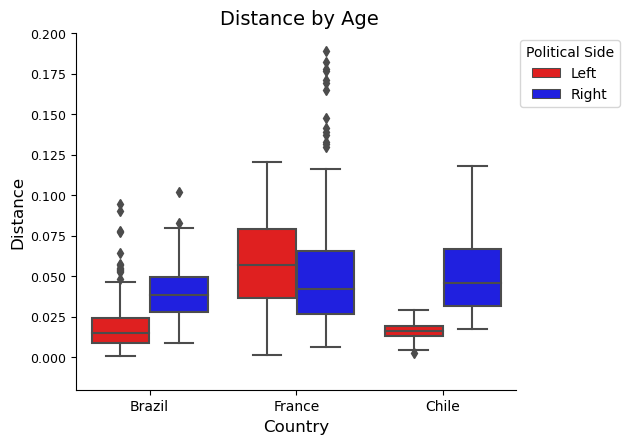

In [10]:
# Crear un DataFrame con todas las distancias
data = {
    'Country': ['Brazil'] * len(distancias_iz_brasil) + ['Brazil'] * len(distancias_der_brasil) + \
               ['France'] * len(distancias_iz_francia) + ['France'] * len(distancias_der_francia)+ \
               ['Chile'] * len(distancias_iz_chile) + ['Chile'] * len(distancias_der_chile),
               
               
    
    'Political Side': ['Left'] * len(distancias_iz_brasil) + ['Right'] * len(distancias_der_brasil) + \
                    ['Left'] * len(distancias_iz_francia) + ['Right'] * len(distancias_der_francia) + \
                    ['Left'] * len(distancias_iz_chile) + ['Right'] * len(distancias_der_chile),
                      
                      
    
    'Distance':  distancias_iz_brasil +  distancias_der_brasil + \
                distancias_iz_francia + distancias_der_francia + \
                distancias_iz_chile + distancias_der_chile
                
}

df = pd.DataFrame(data)

# Definir el orden de los países y los lados políticos
political_side_order = ['Left', 'Right']
country_order = ['Brazil', 'France','Chile']

# Crear facetas para las distancias
g = sns.catplot(x='Country', y='Distance', hue='Political Side', 
                data=df, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                 height=4.3, aspect=1.27, order=country_order)

# Ajustar títulos y ejes
g.set_axis_labels('Country', 'Distance', fontsize=12)
plt.suptitle('Distance by Age', y=1.02, fontsize=14)
plt.ylim(-0.02, 0.20)


for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)  # Ajusta el tamaño de las etiquetas en el eje y

# Eliminar la leyenda automática
g._legend.remove()

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), title='Political Side', 
           fontsize=10, title_fontsize=10)


## Chile

In [11]:

# Cargar datos de cada generación
generation_z = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation Z (Centennials).xlsx')
generation_y = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation Y (Millennials).xlsx')
generation_x = pd.read_excel('Coordenadas/Coordenadas_peaks_Generation X.xlsx')
baby_boomers = pd.read_excel('Coordenadas/Coordenadas_peaks_Baby Boomers.xlsx')
silent_generation = pd.read_excel('Coordenadas/Coordenadas_peaks_Silent Generation.xlsx')

# Filtrar por política para cada generación
generation_z_der = generation_z[generation_z['Politica'] == 'Right']
generation_z_iz = generation_z[generation_z['Politica'] == 'Left']

generation_y_der = generation_y[generation_y['Politica'] == 'Right']
generation_y_iz = generation_y[generation_y['Politica'] == 'Left']

generation_x_der = generation_x[generation_x['Politica'] == 'Right']
generation_x_iz = generation_x[generation_x['Politica'] == 'Left']

baby_boomers_der = baby_boomers[baby_boomers['Politica'] == 'Right']
baby_boomers_iz = baby_boomers[baby_boomers['Politica'] == 'Left']

silent_generation_der = silent_generation[silent_generation['Politica'] == 'Right']
silent_generation_iz = silent_generation[silent_generation['Politica'] == 'Left']

In [12]:
distancias_genz = []
# Calcular la distancia entre todas las filas
for i in range(len(chile_mayores40_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genz = np.sqrt((z1_der_genz - z1_iz_genz) ** 2 + (z2_der_genz - z2_iz_genz) ** 2)

    
    # Agregar la distancia a la lista
    distancias_genz.append(distancia_genz)
    
    import numpy as np

# Listas para almacenar distancias de cada generación
distancias_genz = []
distancias_geny = []
distancias_genx = []
distancias_baby_boomers = []
distancias_silent = []

# Calcular la distancia para Generation Z
for i in range(len(generation_z_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genz = np.sqrt((z1_der_genz - z1_iz_genz) ** 2 + (z2_der_genz - z2_iz_genz) ** 2)

    # Agregar la distancia a la lista
    distancias_genz.append(distancia_genz)

# Calcular la distancia para Generation Y (Millennials)
for i in range(len(generation_y_iz)):
    z1_iz_geny = generation_y_iz.iloc[i]['z1']
    z2_iz_geny = generation_y_iz.iloc[i]['z2']
    
    z1_der_geny = generation_y_der.iloc[i]['z1']
    z2_der_geny = generation_y_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_geny = np.sqrt((z1_der_geny - z1_iz_geny) ** 2 + (z2_der_geny - z2_iz_geny) ** 2)

    # Agregar la distancia a la lista
    distancias_geny.append(distancia_geny)

# Calcular la distancia para Generation X
for i in range(len(generation_x_iz)):
    z1_iz_genx = generation_x_iz.iloc[i]['z1']
    z2_iz_genx = generation_x_iz.iloc[i]['z2']
    
    z1_der_genx = generation_x_der.iloc[i]['z1']
    z2_der_genx = generation_x_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_genx = np.sqrt((z1_der_genx - z1_iz_genx) ** 2 + (z2_der_genx - z2_iz_genx) ** 2)

    # Agregar la distancia a la lista
    distancias_genx.append(distancia_genx)

# Calcular la distancia para Baby Boomers
for i in range(len(baby_boomers_iz)):
    z1_iz_baby = baby_boomers_iz.iloc[i]['z1']
    z2_iz_baby = baby_boomers_iz.iloc[i]['z2']
    
    z1_der_baby = baby_boomers_der.iloc[i]['z1']
    z2_der_baby = baby_boomers_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_baby = np.sqrt((z1_der_baby - z1_iz_baby) ** 2 + (z2_der_baby - z2_iz_baby) ** 2)

    # Agregar la distancia a la lista
    distancias_baby_boomers.append(distancia_baby)

# Calcular la distancia para Silent Generation
for i in range(len(silent_generation_iz)):
    z1_iz_silent = silent_generation_iz.iloc[i]['z1']
    z2_iz_silent = silent_generation_iz.iloc[i]['z2']
    
    z1_der_silent = silent_generation_der.iloc[i]['z1']
    z2_der_silent = silent_generation_der.iloc[i]['z2']
    
    # Fórmula de distancia
    distancia_silent = np.sqrt((z1_der_silent - z1_iz_silent) ** 2 + (z2_der_silent - z2_iz_silent) ** 2)

    # Agregar la distancia a la lista
    distancias_silent.append(distancia_silent)

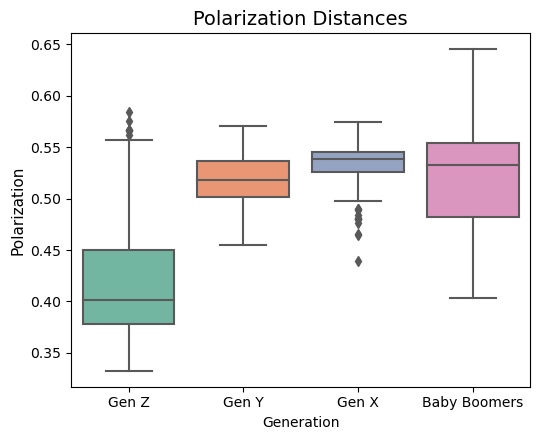

In [13]:

# Combinar las distancias de Baby Boomers y Silent Generation
distancias_baby_silent = distancias_baby_boomers + distancias_silent

# Crear un DataFrame para facilitar la creación del boxplot
data = {
    'Generation': (
        ['Gen Z'] * len(distancias_genz) +
        ['Gen Y'] * len(distancias_geny) +
        ['Gen X'] * len(distancias_genx) +
        ['Baby Boomers'] * len(distancias_baby_silent)
    ),
    'Distance': np.concatenate([
        distancias_genz,
        distancias_geny,
        distancias_genx,
        distancias_baby_silent
    ])
}

df = pd.DataFrame(data)

# Configurar el gráfico
plt.figure(figsize=(5.5, 4.5))
sns.boxplot(x='Generation', y='Distance', data=df, palette="Set2")

# Títulos y etiquetas de los ejes
plt.title('Polarization Distances', fontsize=14)
plt.xlabel('Generation', fontsize=10)
plt.ylabel('Polarization', fontsize=11)

# Ajustar las etiquetas de la leyenda (no se usa leyenda en este caso)
# plt.legend(fontsize=16)  # No es necesario aquí

# Ajustar el tamaño de las etiquetas en los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el gráfico para que no se superpongan los elementos
plt.show()




In [14]:
import numpy as np

# Suponiendo que ya tienes los DataFrames correspondientes para cada generación
# Asegúrate de que estos DataFrames existen y contienen las columnas 'z1' y 'z2'

# Listas para almacenar las distancias
distancias_der_all_genz = []
distancias_iz_all_genz = []

distancias_der_all_geny = []
distancias_iz_all_geny = []

distancias_der_all_genx = []
distancias_iz_all_genx = []

# Supongamos que has unido Baby Boomers y Silent Generation
distancias_der_all_silent = []
distancias_iz_all_silent = []

# Supongamos que has unido Baby Boomers y Silent Generation
distancias_der_all_baby = []
distancias_iz_all_baby = []

# Calcular las distancias para Generación Z
for i in range(len(generation_z_iz)):
    z1_iz_genz = generation_z_iz.iloc[i]['z1']
    z2_iz_genz = generation_z_iz.iloc[i]['z2']
    
    z1_der_genz = generation_z_der.iloc[i]['z1']
    z2_der_genz = generation_z_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_genz = np.sqrt((z1_der_all - z1_der_genz) ** 2 + (z2_der_all - z2_der_genz) ** 2)
    distancia_iz_all_genz = np.sqrt((z1_iz_all - z1_iz_genz) ** 2 + (z2_iz_all - z2_iz_genz) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_genz.append(distancia_der_all_genz)
    distancias_iz_all_genz.append(distancia_iz_all_genz)

# Calcular las distancias para Generación Y (Millennials)
for i in range(len(generation_y_iz)):  # Asegúrate de que tienes este DataFrame
    z1_iz_geny = generation_y_iz.iloc[i]['z1']
    z2_iz_geny = generation_y_iz.iloc[i]['z2']
    
    z1_der_geny = generation_y_der.iloc[i]['z1']
    z2_der_geny = generation_y_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_geny = np.sqrt((z1_der_all - z1_der_geny) ** 2 + (z2_der_all - z2_der_geny) ** 2)
    distancia_iz_all_geny = np.sqrt((z1_iz_all - z1_iz_geny) ** 2 + (z2_iz_all - z2_iz_geny) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_geny.append(distancia_der_all_geny)
    distancias_iz_all_geny.append(distancia_iz_all_geny)

# Calcular las distancias para Generación X
for i in range(len(generation_x_iz)):  # Asegúrate de que tienes este DataFrame
    z1_iz_genx = generation_x_iz.iloc[i]['z1']
    z2_iz_genx = generation_x_iz.iloc[i]['z2']
    
    z1_der_genx = generation_x_der.iloc[i]['z1']
    z2_der_genx = generation_x_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_genx = np.sqrt((z1_der_all - z1_der_genx) ** 2 + (z2_der_all - z2_der_genx) ** 2)
    distancia_iz_all_genx = np.sqrt((z1_iz_all - z1_iz_genx) ** 2 + (z2_iz_all - z2_iz_genx) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_genx.append(distancia_der_all_genx)
    distancias_iz_all_genx.append(distancia_iz_all_genx)

# Calcular las distancias para Baby Boomers y Silent Generation
for i in range(len(silent_generation_iz)):  # Asegúrate de que tienes este DataFrame combinado
    z1_iz_silent = silent_generation_iz.iloc[i]['z1']
    z2_iz_silent = silent_generation_iz.iloc[i]['z2']
    
    z1_der_silent = silent_generation_der.iloc[i]['z1']
    z2_der_silent = silent_generation_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_silent = np.sqrt((z1_der_all - z1_der_silent) ** 2 + (z2_der_all - z2_der_silent) ** 2)
    distancia_iz_all_silent = np.sqrt((z1_iz_all - z1_iz_silent) ** 2 + (z2_iz_all - z2_iz_silent) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_silent.append(distancia_der_all_silent)
    distancias_iz_all_silent.append(distancia_iz_all_silent)

    
    
    
# Calcular las distancias para Baby Boomers y Silent Generation
for i in range(len(baby_boomers_der)):  # Asegúrate de que tienes este DataFrame combinado
    z1_iz_baby = baby_boomers_iz.iloc[i]['z1']
    z2_iz_baby= baby_boomers_iz.iloc[i]['z2']
    
    z1_der_baby = baby_boomers_der.iloc[i]['z1']
    z2_der_baby = baby_boomers_der.iloc[i]['z2']
    
    z1_iz_all = iz_chile.iloc[i]['z1']  # Reemplaza con el DataFrame correcto
    z2_iz_all = iz_chile.iloc[i]['z2']
    z1_der_all = der_chile.iloc[i]['z1']
    z2_der_all = der_chile.iloc[i]['z2']
    
    # Calcular distancias
    distancia_der_all_baby = np.sqrt((z1_der_all - z1_der_baby) ** 2 + (z2_der_all - z2_der_baby) ** 2)
    distancia_iz_all_baby = np.sqrt((z1_iz_all - z1_iz_baby) ** 2 + (z2_iz_all - z2_iz_baby) ** 2)

    # Agregar distancias a las listas
    distancias_der_all_baby.append(distancia_der_all_baby)
    distancias_iz_all_baby.append(distancia_iz_all_baby)



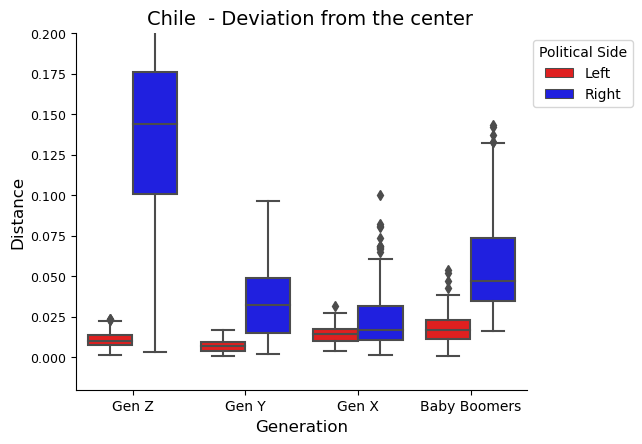

In [15]:

# Combinar las distancias de Baby Boomers y Silent Generation
distancias_der_all_baby_silent = distancias_der_all_silent + distancias_der_all_baby 
distancias_iz_all_baby_silent = distancias_iz_all_silent + distancias_iz_all_baby 
# Crear un DataFrame con todas las distancias
data = {
    'Generation': ['Gen Z'] * len(distancias_der_all_genz) + ['Gen Z'] * len(distancias_iz_all_genz) + \
                  ['Gen Y'] * len(distancias_der_all_geny) + ['Gen Y'] * len(distancias_iz_all_geny) + \
                  ['Gen X'] * len(distancias_der_all_genx) + ['Gen X'] * len(distancias_iz_all_genx) + \
                  ['Baby Boomers'] * len(distancias_der_all_baby_silent) + ['Baby Boomers'] * len(distancias_iz_all_baby_silent),
    
    'Political Side': ['Left'] * len(distancias_iz_all_genz) + ['Right'] * len(distancias_der_all_genz) + \
                      ['Left'] * len(distancias_iz_all_geny) + ['Right'] * len(distancias_der_all_geny) + \
                      ['Left'] * len(distancias_iz_all_genx) + ['Right'] * len(distancias_der_all_genx) + \
                      ['Left'] * len(distancias_iz_all_baby_silent) + ['Right'] * len(distancias_der_all_baby_silent),
    
    'Distance': distancias_iz_all_genz + distancias_der_all_genz + \
                distancias_iz_all_geny + distancias_der_all_geny + \
                distancias_iz_all_genx + distancias_der_all_genx + \
                distancias_iz_all_baby_silent + distancias_der_all_baby_silent
}

df = pd.DataFrame(data)


# Definir el orden de las generaciones y los lados políticos

political_side_order = ['Left', 'Right']


# Crear facetas para las distancias
g = sns.catplot(x='Generation', y='Distance', hue='Political Side', 
                data=df, kind='box', palette={'Left': 'red', 'Right': 'blue'}, 
                height=4.3, aspect=1.27)

# Ajustar títulos y ejes
g.set_axis_labels('Generation', 'Distance',fontsize=12)
plt.suptitle('Chile  - Deviation from the center', y=1.02,fontsize=14)
plt.ylim(-0.02, 0.20)


for ax in g.axes.flat:
    ax.tick_params(axis='y', labelsize=9)  # Ajusta el tamaño de las etiquetas en el eje y

# Eliminar la leyenda automática
g._legend.remove()

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), title='Political Side', 
           fontsize=10, title_fontsize=10)